# Guía Completa: Tratamiento de Datos Discretos y Continuos

## Objetivos de Aprendizaje

En este notebook aprenderás a trabajar con los dos tipos fundamentales de datos cuantitativos:

- **Datos Discretos**: Valores que pueden contarse (enteros, categorías numeradas)
- **Datos Continuos**: Valores que pueden medirse en una escala continua

### Lo que aprenderás:

- **Identificación y creación** de datos discretos y continuos
- **Técnicas de visualización** específicas para cada tipo
- **Análisis estadístico** apropiado para cada categoría
- **Transformaciones y binning** para cambiar entre tipos
- **Comparaciones y diferencias** fundamentales
- **Aplicaciones prácticas** en análisis de datos

Entender estas diferencias es crucial para aplicar las técnicas correctas de análisis y visualización en tus proyectos.

## 1. Importar Librerías Necesarias

Comenzaremos importando todas las librerías que necesitaremos para generar, analizar y visualizar datos discretos y continuos.

In [2]:
# Librerías fundamentales para manejo de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para análisis estadístico
from scipy import stats
from scipy.stats import norm, poisson, binom, expon, uniform
import scipy.stats as st

# Configuraciones para visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Configurar pandas
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Suprimir warnings
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
np.random.seed(42)

print("Librerías importadas correctamente!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
# print(f"SciPy version: {st.__version__}")

Librerías importadas correctamente!
Pandas version: 2.2.3
NumPy version: 1.26.4
Matplotlib version: 3.10.1
Seaborn version: 0.13.2


## 2. Crear Datos Discretos

Los datos discretos son valores que pueden contarse y generalmente son números enteros. Exploraremos diferentes distribuciones discretas.

In [ ]:
print("GENERACIÓN DE DATOS DISCRETOS")
print("=" * 35)

# Tamaño de las muestras
n_samples = 1000

# 1. Distribución Binomial - Número de éxitos en n ensayos
# Ejemplo: Número de clientes que compran de 10 que visitan la tienda
binomial_data = np.random.binomial(n=10, p=0.3, size=n_samples)
print(f"Distribución Binomial (n=10, p=0.3):")
print(f"  Rango: {binomial_data.min()} - {binomial_data.max()}")
print(f"  Media: {binomial_data.mean():.2f}")
print(f"  Valores únicos: {len(np.unique(binomial_data))}")

# 2. Distribución de Poisson - Número de eventos en un período fijo
# Ejemplo: Número de llamadas telefónicas por hora
poisson_data = np.random.poisson(lam=4, size=n_samples)
print(f"\nDistribución Poisson (λ=4):")
print(f"  Rango: {poisson_data.min()} - {poisson_data.max()}")
print(f"  Media: {poisson_data.mean():.2f}")
print(f"  Valores únicos: {len(np.unique(poisson_data))}")

# 3. Distribución Uniforme Discreta - Valores igualmente probables
# Ejemplo: Resultado de lanzar un dado
uniform_discrete = np.random.randint(1, 7, size=n_samples)
print(f"\nDistribución Uniforme Discreta (1-6):")
print(f"  Rango: {uniform_discrete.min()} - {uniform_discrete.max()}")
print(f"  Media: {uniform_discrete.mean():.2f}")
print(f"  Valores únicos: {len(np.unique(uniform_discrete))}")

# 4. Variable categórica numérica - Número de hijos
num_hijos = np.random.choice([0, 1, 2, 3, 4, 5], size=n_samples, 
                            p=[0.2, 0.3, 0.25, 0.15, 0.07, 0.03])
print(f"\nNúmero de hijos (categórica):")
print(f"  Rango: {num_hijos.min()} - {num_hijos.max()}")
print(f"  Media: {num_hijos.mean():.2f}")
print(f"  Valores únicos: {len(np.unique(num_hijos))}")

# Crear DataFrame con datos discretos
datos_discretos = pd.DataFrame({
    'binomial': binomial_data,
    'poisson': poisson_data,
    'dado': uniform_discrete,
    'num_hijos': num_hijos
})

print(f"\nDataFrame creado con {datos_discretos.shape[0]} filas y {datos_discretos.shape[1]} variables discretas")
print("\nPrimeras 10 observaciones:")


GENERACIÓN DE DATOS DISCRETOS
Distribución Binomial (n=10, p=0.3):
  Rango: 0 - 8
  Media: 2.94
  Valores únicos: 9

Distribución Poisson (λ=4):
  Rango: 0 - 10
  Media: 3.97
  Valores únicos: 11

Distribución Uniforme Discreta (1-6):
  Rango: 1 - 6
  Media: 3.49
  Valores únicos: 6

Número de hijos (categórica):
  Rango: 0 - 5
  Media: 1.69
  Valores únicos: 6

DataFrame creado con 1000 filas y 4 variables discretas

Primeras 10 observaciones:
   binomial  poisson  dado  num_hijos
0         2        8     6          2
1         5        4     6          0
2         4        5     6          3
3         3        9     5          1
4         2        2     1          0
5         2        1     5          1
6         1        3     3          1
7         5        6     5          1
8         3        1     3          2
9         4        2     3          2


## 3. Crear Datos Continuos

Los datos continuos pueden tomar cualquier valor dentro de un rango y se miden en escalas continuas.

In [4]:
print("GENERACIÓN DE DATOS CONTINUOS")
print("=" * 35)

# 1. Distribución Normal - La más común en la naturaleza
# Ejemplo: Altura de personas, peso, temperaturas
normal_data = np.random.normal(loc=170, scale=10, size=n_samples)  # Altura en cm
print(f"Distribución Normal (μ=170, σ=10):")
print(f"  Rango: {normal_data.min():.2f} - {normal_data.max():.2f}")
print(f"  Media: {normal_data.mean():.2f}")
print(f"  Desviación estándar: {normal_data.std():.2f}")


GENERACIÓN DE DATOS CONTINUOS
Distribución Normal (μ=170, σ=10):
  Rango: 133.03 - 204.14
  Media: 169.79
  Desviación estándar: 9.82


In [5]:

# 2. Distribución Exponencial - Tiempo entre eventos
# Ejemplo: Tiempo entre llegadas de clientes, vida útil de productos
exponential_data = np.random.exponential(scale=2, size=n_samples)
print(f"\nDistribución Exponencial (λ=0.5):")
print(f"  Rango: {exponential_data.min():.2f} - {exponential_data.max():.2f}")
print(f"  Media: {exponential_data.mean():.2f}")
print(f"  Desviación estándar: {exponential_data.std():.2f}")



Distribución Exponencial (λ=0.5):
  Rango: 0.00 - 15.19
  Media: 1.97
  Desviación estándar: 1.97


In [6]:

# 3. Distribución Uniforme Continua - Todos los valores igualmente probables
# Ejemplo: Números aleatorios, ángulos, proporciones
uniform_continuous = np.random.uniform(low=0, high=100, size=n_samples)
print(f"\nDistribución Uniforme Continua (0-100):")
print(f"  Rango: {uniform_continuous.min():.2f} - {uniform_continuous.max():.2f}")
print(f"  Media: {uniform_continuous.mean():.2f}")
print(f"  Desviación estándar: {uniform_continuous.std():.2f}")



Distribución Uniforme Continua (0-100):
  Rango: 0.02 - 99.96
  Media: 49.98
  Desviación estándar: 28.42


In [7]:

# 4. Distribución Log-Normal - Datos financieros, ingresos
# Ejemplo: Salarios, precios de acciones
lognormal_data = np.random.lognormal(mean=10, sigma=0.5, size=n_samples)
print(f"\nDistribución Log-Normal (μ=10, σ=0.5):")
print(f"  Rango: {lognormal_data.min():.2f} - {lognormal_data.max():.2f}")
print(f"  Media: {lognormal_data.mean():.2f}")
print(f"  Desviación estándar: {lognormal_data.std():.2f}")



Distribución Log-Normal (μ=10, σ=0.5):
  Rango: 4408.59 - 86447.14
  Media: 24867.73
  Desviación estándar: 12645.48


In [8]:

# 5. Variable continua real - Temperatura
temperatura = np.random.normal(25, 5, n_samples) + np.random.normal(0, 2, n_samples)
print(f"\nTemperatura (°C):")
print(f"  Rango: {temperatura.min():.2f} - {temperatura.max():.2f}")
print(f"  Media: {temperatura.mean():.2f}")



Temperatura (°C):
  Rango: 7.84 - 43.68
  Media: 24.97


In [9]:

# Crear DataFrame con datos continuos
datos_continuos = pd.DataFrame({
    'altura_cm': normal_data,
    'tiempo_espera': exponential_data,
    'porcentaje': uniform_continuous,
    'salario': lognormal_data,
    'temperatura': temperatura
})

print(f"\nDataFrame creado con {datos_continuos.shape[0]} filas y {datos_continuos.shape[1]} variables continuas")
print("\nPrimeras 10 observaciones:")
print(datos_continuos.head(10))


DataFrame creado con 1000 filas y 5 variables continuas

Primeras 10 observaciones:
    altura_cm  tiempo_espera  porcentaje       salario  temperatura
0  169.547252       0.435585    1.833839  42900.865432    29.803087
1  159.556034       0.056490   12.762319  19068.230689    26.020431
2  180.540363       3.269664   75.423132  13221.179623    24.675971
3  177.005637       0.039431   47.154013  14365.175490    22.309895
4  183.065396       3.552043   14.983813  30790.164016    26.548656
5  172.902091       0.311213   26.396085  68067.914310    12.725143
6  164.794031       7.352196   94.783690  16949.754999    25.017193
7  175.168885       1.852045   36.713284  64493.051138    28.461209
8  173.263292       2.655922   90.768195  21907.396888    24.375746
9  164.251263       0.234155   30.463583  19150.687314    28.513631


## 4. Visualizar Datos Discretos

Los datos discretos requieren técnicas de visualización específicas que muestren claramente los valores individuales y sus frecuencias.

In [11]:
display(datos_discretos.head(10))

,binomial,poisson,dado,num_hijos
0,2,8,6,2
1,5,4,6,0
2,4,5,6,3
3,3,9,5,1
4,2,2,1,0
5,2,1,5,1
6,1,3,3,1
7,5,6,5,1
8,3,1,3,2
9,4,2,3,2


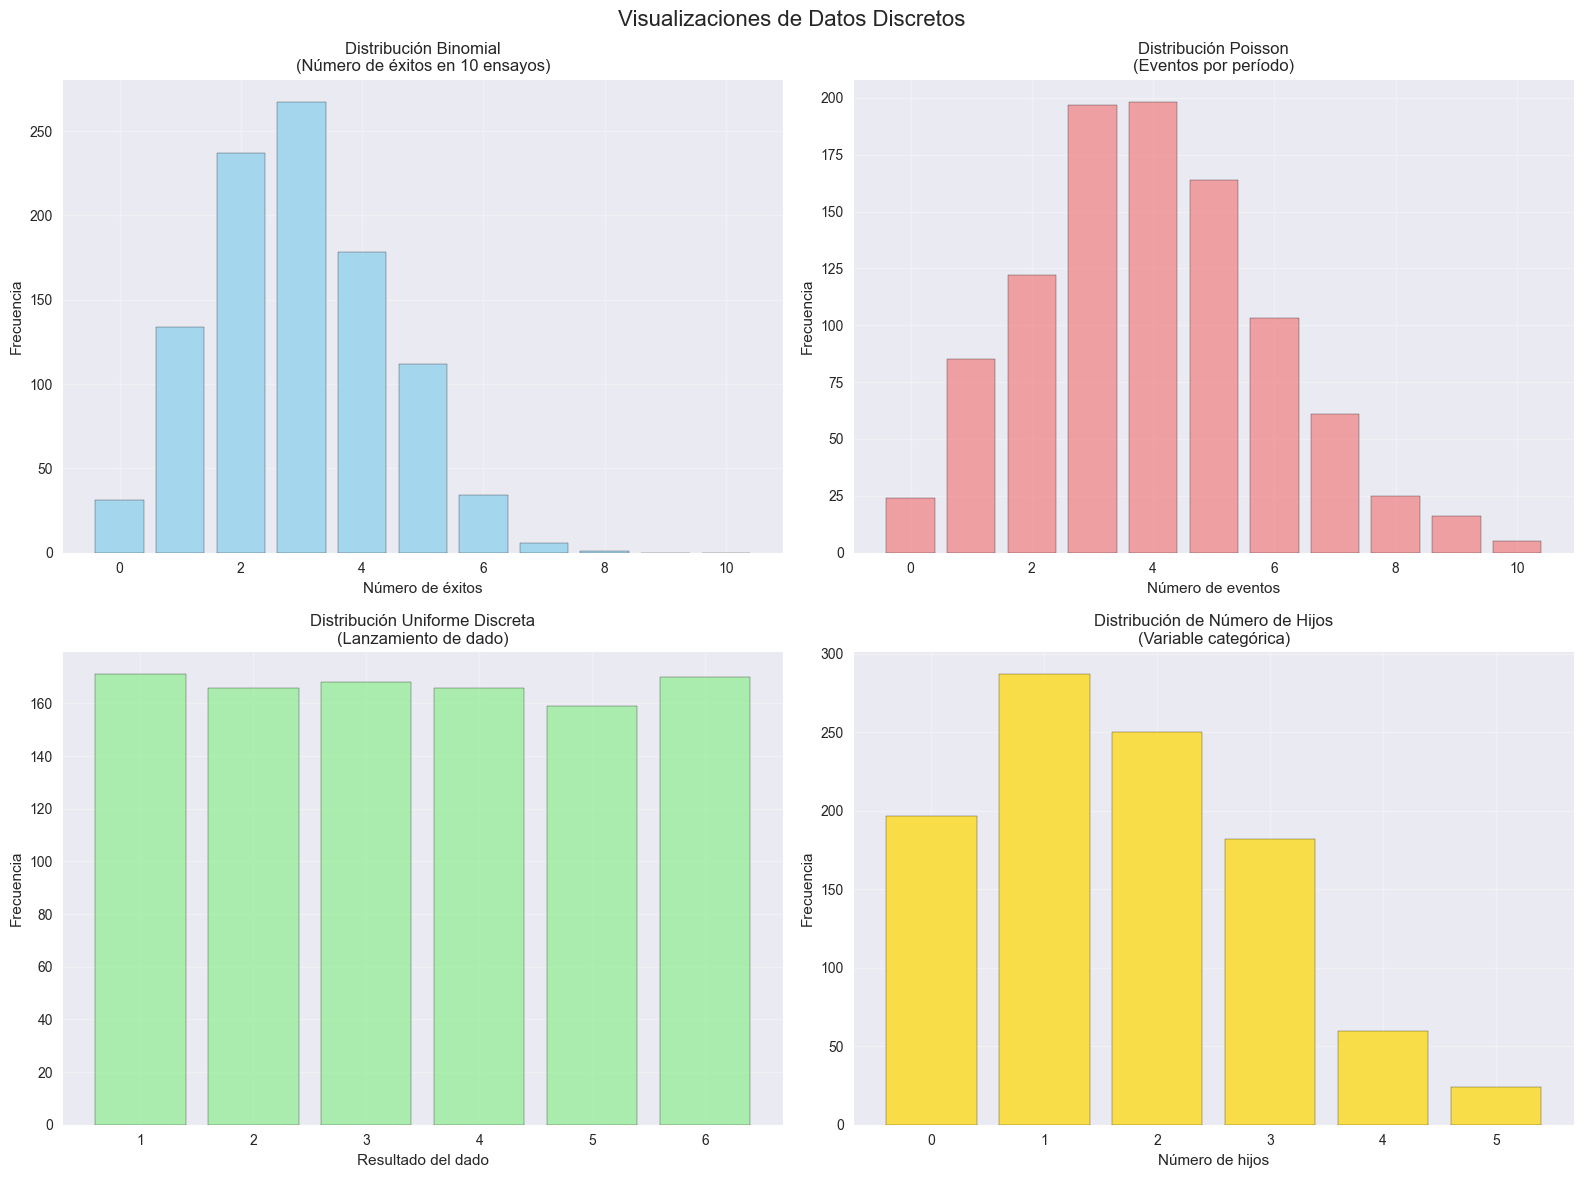

In [12]:
# Visualizaciones para datos discretos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Visualizaciones de Datos Discretos', fontsize=16)

# 1. Gráfico de barras para distribución binomial
valores_binomial = np.arange(0, 11)
frecuencias_binomial = [np.sum(datos_discretos['binomial'] == i) for i in valores_binomial]

axes[0, 0].bar(valores_binomial, frecuencias_binomial, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribución Binomial\n(Número de éxitos en 10 ensayos)')
axes[0, 0].set_xlabel('Número de éxitos')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(True, alpha=0.3)

# 2. Gráfico de barras para distribución de Poisson
valores_poisson = np.arange(0, datos_discretos['poisson'].max() + 1)
frecuencias_poisson = [np.sum(datos_discretos['poisson'] == i) for i in valores_poisson]

axes[0, 1].bar(valores_poisson, frecuencias_poisson, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribución Poisson\n(Eventos por período)')
axes[0, 1].set_xlabel('Número de eventos')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(True, alpha=0.3)

# 3. Gráfico de barras para dado (uniforme discreta)
valores_dado = np.arange(1, 7)
frecuencias_dado = [np.sum(datos_discretos['dado'] == i) for i in valores_dado]

axes[1, 0].bar(valores_dado, frecuencias_dado, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribución Uniforme Discreta\n(Lanzamiento de dado)')
axes[1, 0].set_xlabel('Resultado del dado')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(True, alpha=0.3)

# 4. Gráfico de barras para número de hijos
valores_hijos = np.arange(0, 6)
frecuencias_hijos = [np.sum(datos_discretos['num_hijos'] == i) for i in valores_hijos]

axes[1, 1].bar(valores_hijos, frecuencias_hijos, alpha=0.7, color='gold', edgecolor='black')
axes[1, 1].set_title('Distribución de Número de Hijos\n(Variable categórica)')
axes[1, 1].set_xlabel('Número de hijos')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:

# Tabla de frecuencias para datos discretos
print("TABLAS DE FRECUENCIAS PARA DATOS DISCRETOS")
print("=" * 45)

for columna in datos_discretos.columns:
    print(f"\n{columna.upper()}:")
    tabla_frecuencias = datos_discretos[columna].value_counts().sort_index()
    tabla_porcentajes = (tabla_frecuencias / len(datos_discretos) * 100).round(2)
    
    resultado = pd.DataFrame({
        'Valor': tabla_frecuencias.index,
        'Frecuencia': tabla_frecuencias.values,
        'Porcentaje': tabla_porcentajes.values
    })
    print(resultado.head(10).to_string(index=False))

TABLAS DE FRECUENCIAS PARA DATOS DISCRETOS

BINOMIAL:
 Valor  Frecuencia  Porcentaje
     0          31         3.1
     1         134        13.4
     2         237        23.7
     3         267        26.7
     4         178        17.8
     5         112        11.2
     6          34         3.4
     7           6         0.6
     8           1         0.1

POISSON:
 Valor  Frecuencia  Porcentaje
     0          24         2.4
     1          85         8.5
     2         122        12.2
     3         197        19.7
     4         198        19.8
     5         164        16.4
     6         103        10.3
     7          61         6.1
     8          25         2.5
     9          16         1.6

DADO:
 Valor  Frecuencia  Porcentaje
     1         171        17.1
     2         166        16.6
     3         168        16.8
     4         166        16.6
     5         159        15.9
     6         170        17.0

NUM_HIJOS:
 Valor  Frecuencia  Porcentaje
     0         197

## 5. Visualizar Datos Continuos

Los datos continuos se visualizan mejor con histogramas, gráficos de densidad y diagramas de caja que muestran la distribución continua.

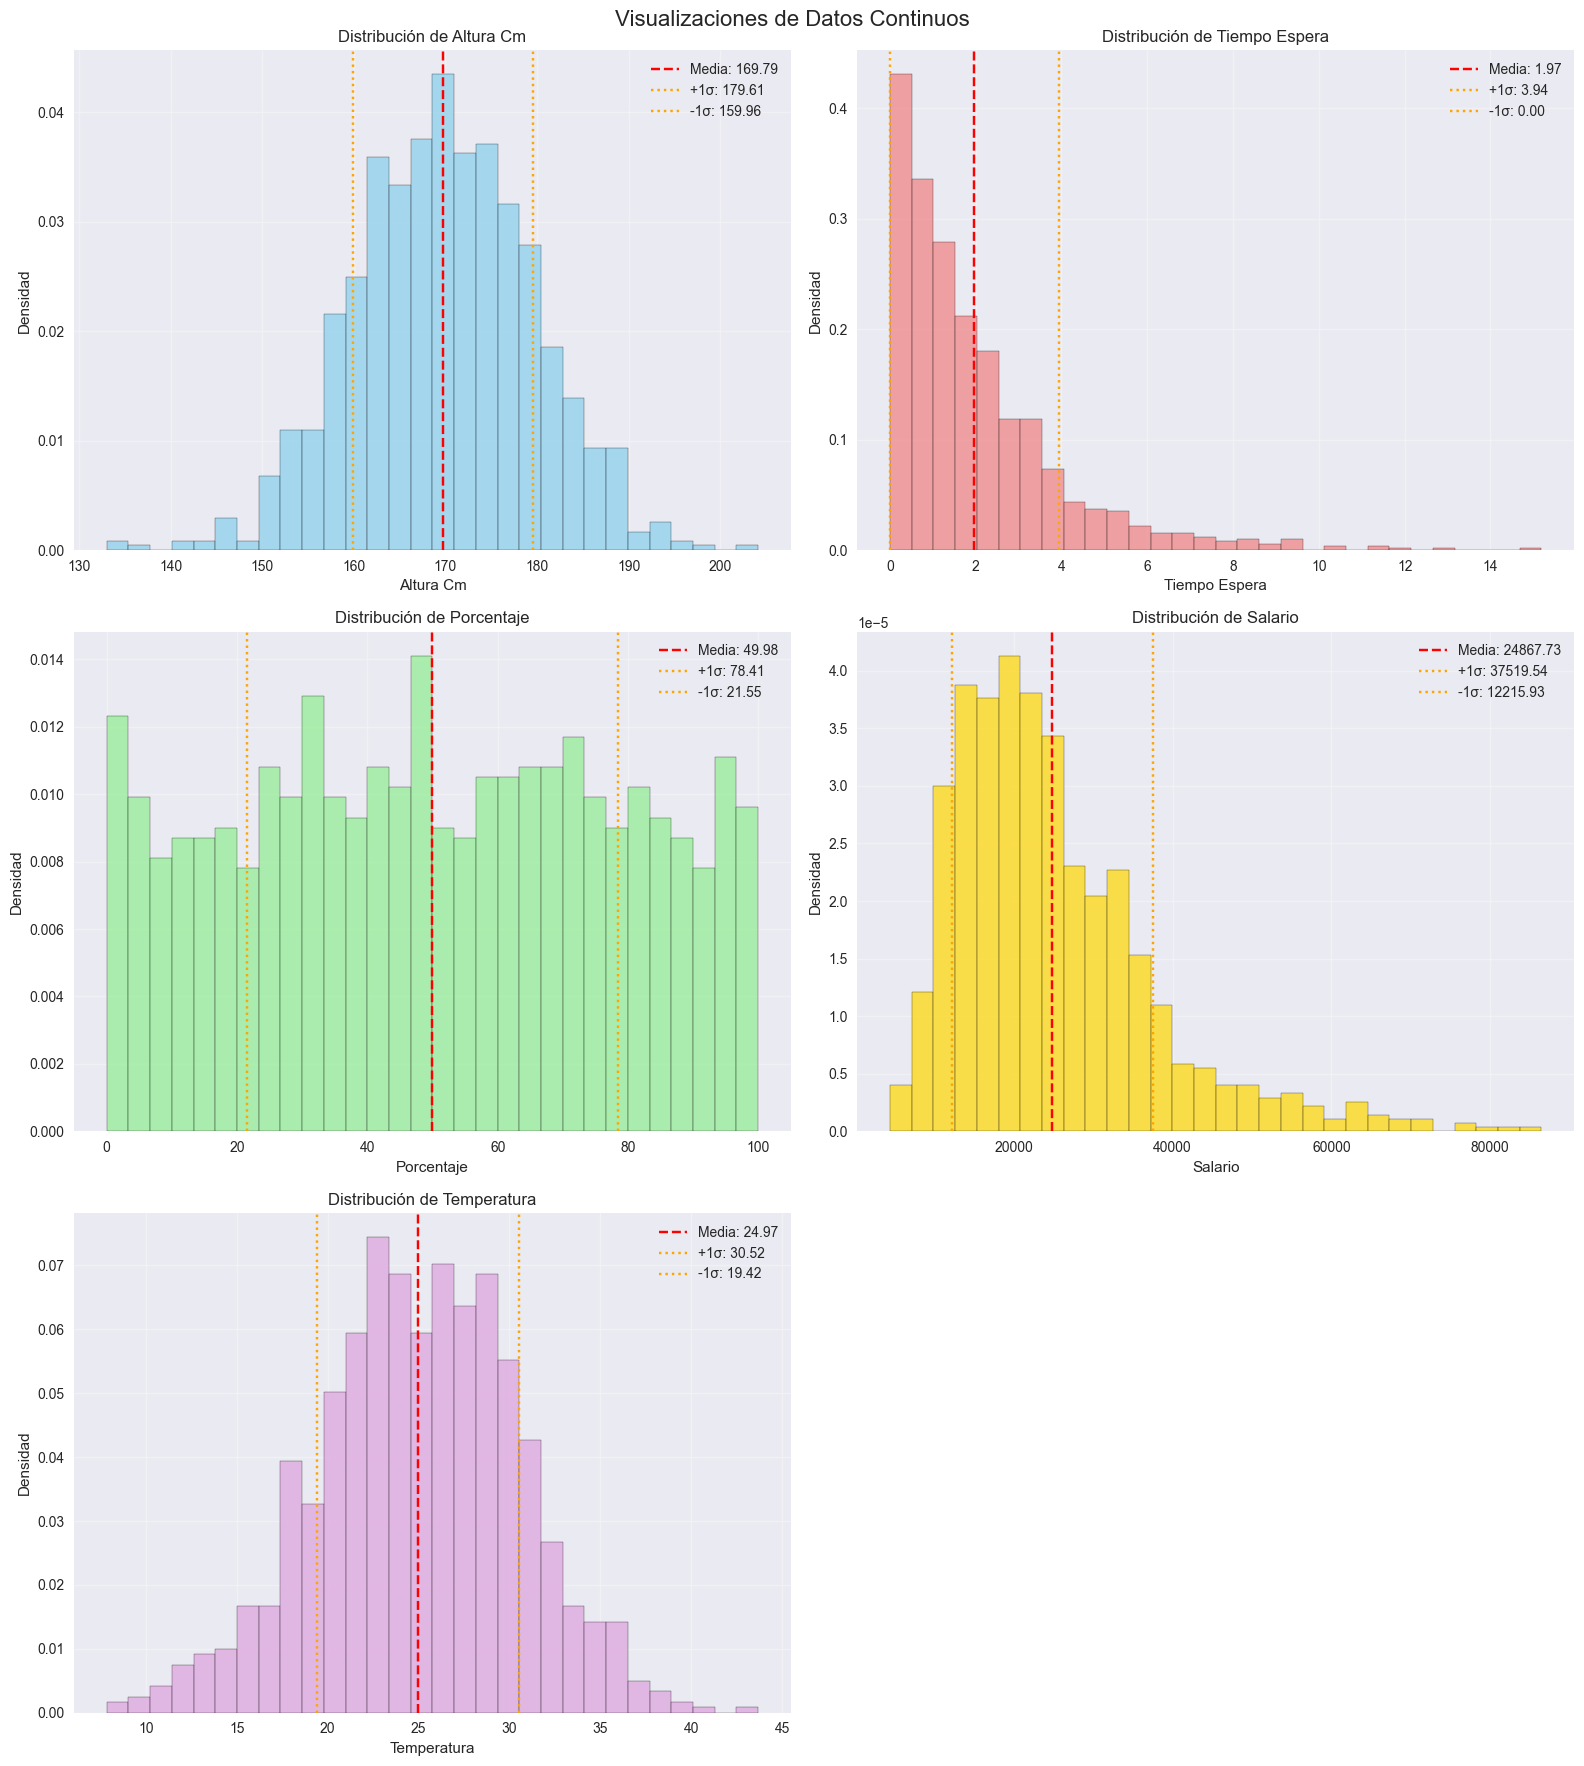

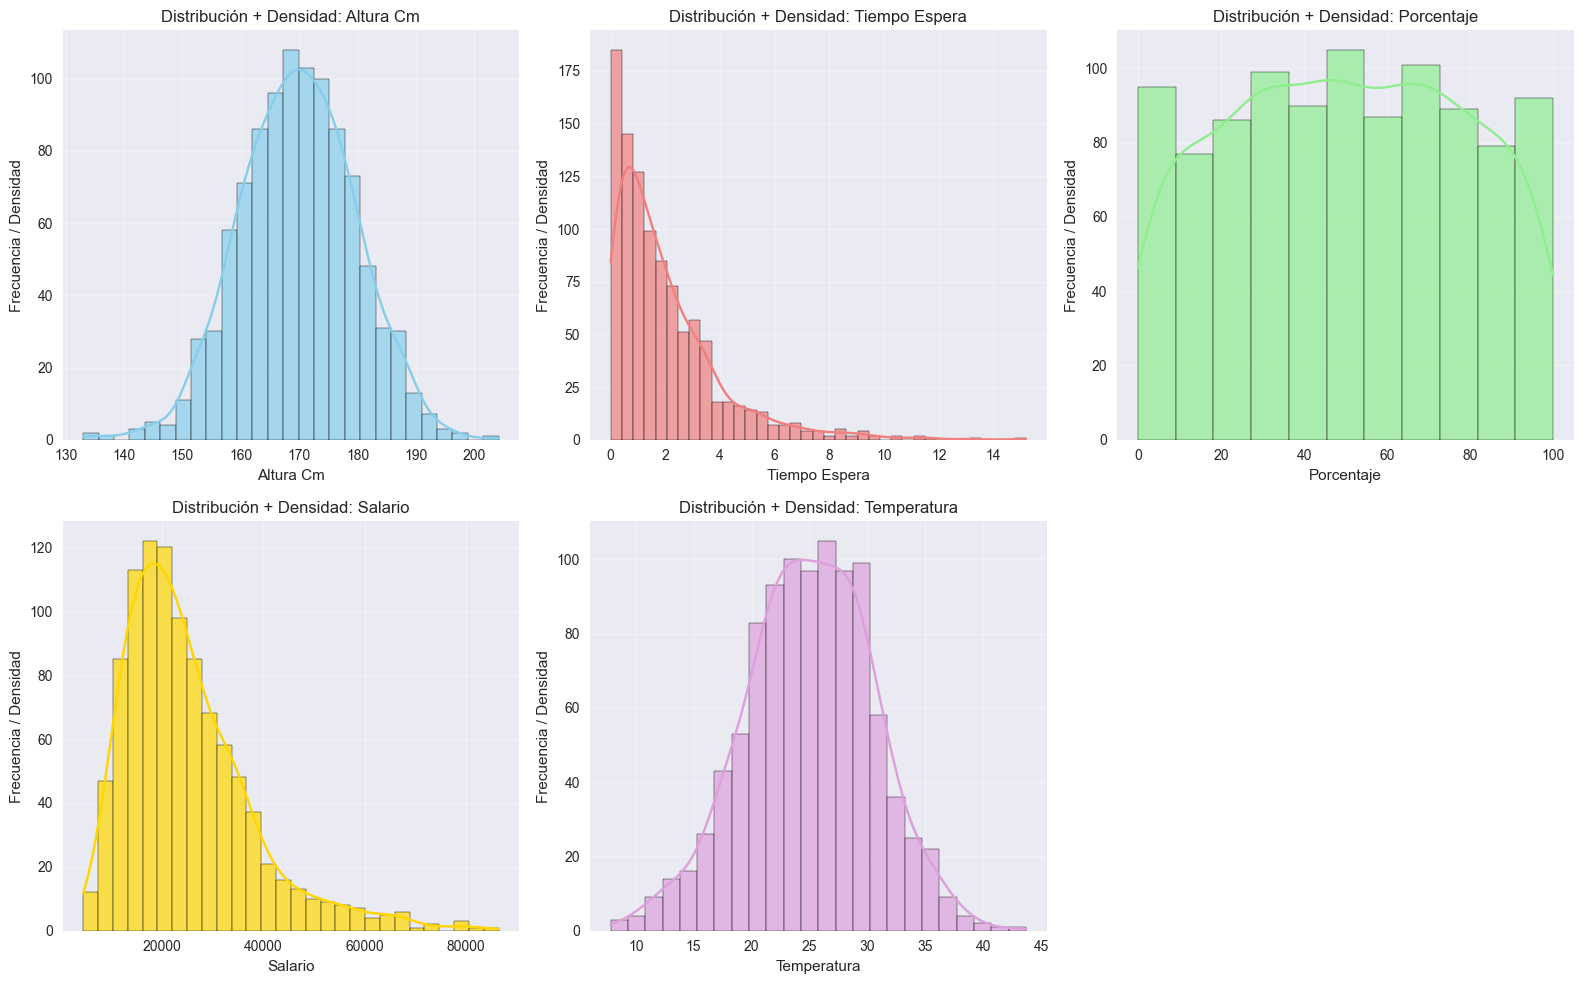

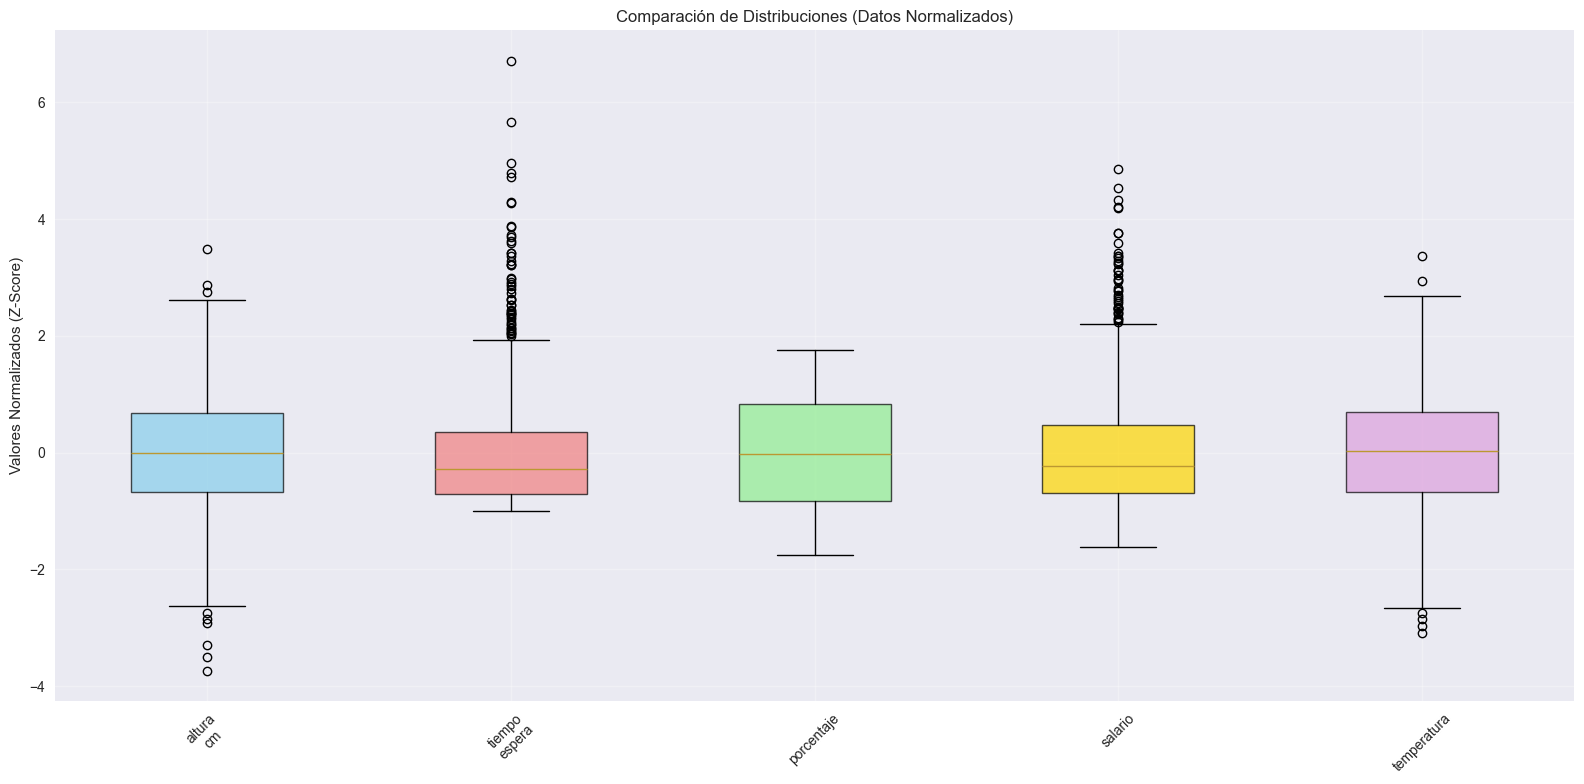

In [14]:
# Visualizaciones para datos continuos
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Visualizaciones de Datos Continuos', fontsize=16)

variables_continuas = ['altura_cm', 'tiempo_espera', 'porcentaje', 'salario', 'temperatura']
colores = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']

# Histogramas
for i, (var, color) in enumerate(zip(variables_continuas, colores)):
    row = i // 2
    col = i % 2
    
    # Histograma
    axes[row, col].hist(datos_continuos[var], bins=30, alpha=0.7, 
                       color=color, edgecolor='black', density=True)
    axes[row, col].set_title(f'Distribución de {var.replace("_", " ").title()}')
    axes[row, col].set_xlabel(var.replace('_', ' ').title())
    axes[row, col].set_ylabel('Densidad')
    axes[row, col].grid(True, alpha=0.3)
    
    # Agregar estadísticas al gráfico
    media = datos_continuos[var].mean()
    std = datos_continuos[var].std()
    axes[row, col].axvline(media, color='red', linestyle='--', 
                          label=f'Media: {media:.2f}')
    axes[row, col].axvline(media + std, color='orange', linestyle=':', 
                          label=f'+1σ: {media + std:.2f}')
    axes[row, col].axvline(media - std, color='orange', linestyle=':', 
                          label=f'-1σ: {media - std:.2f}')
    axes[row, col].legend(fontsize=10)

# Usar el último subplot para un resumen
axes[2, 1].remove()

plt.tight_layout()
plt.show()

# Gráficos de densidad usando seaborn
plt.figure(figsize=(16, 10))

for i, var in enumerate(variables_continuas):
    plt.subplot(2, 3, i+1)
    sns.histplot(datos_continuos[var], kde=True, alpha=0.7, color=colores[i])
    plt.title(f'Distribución + Densidad: {var.replace("_", " ").title()}')
    plt.xlabel(var.replace('_', ' ').title())
    plt.ylabel('Frecuencia / Densidad')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Boxplots para visualizar distribuciones y outliers
plt.figure(figsize=(16, 8))
datos_continuos_norm = datos_continuos.copy()

# Normalizar datos para comparación visual
for col in datos_continuos_norm.columns:
    datos_continuos_norm[col] = (datos_continuos_norm[col] - datos_continuos_norm[col].mean()) / datos_continuos_norm[col].std()

box_plot = plt.boxplot([datos_continuos_norm[col] for col in datos_continuos_norm.columns], 
                      labels=[col.replace('_', '\n') for col in datos_continuos_norm.columns],
                      patch_artist=True)

for patch, color in zip(box_plot['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Comparación de Distribuciones (Datos Normalizados)')
plt.ylabel('Valores Normalizados (Z-Score)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Análisis Estadístico de Datos Discretos

Para datos discretos, nos enfocamos en frecuencias, probabilidades y medidas de tendencia central robustas.

In [ ]:
# Función para análisis estadístico de datos discretos
def analisis_estadistico_discreto(serie, nombre):
    """
    Realiza análisis estadístico específico para datos discretos
    """
    print(f"\n=== ANÁLISIS DE {nombre.upper()} ===")
    
    # Estadísticas básicas
    print(f"Medidas de tendencia central:")
    print(f"  Media: {serie.mean():.3f}")
    print(f"  Mediana: {serie.median():.3f}")
    print(f"  Moda: {serie.mode().iloc[0]} (frecuencia: {(serie == serie.mode().iloc[0]).sum()})")
    
    # Medidas de dispersión
    print(f"\nMedidas de dispersión:")
    print(f"  Varianza: {serie.var():.3f}")
    print(f"  Desviación estándar: {serie.std():.3f}")
    print(f"  Rango: {serie.max() - serie.min()}")
    print(f"  Rango intercuartílico (IQR): {serie.quantile(0.75) - serie.quantile(0.25):.3f}")
    
    # Información sobre la distribución
    print(f"\nCaracterísticas de la distribución:")
    print(f"  Valores únicos: {serie.nunique()}")
    print(f"  Valor mínimo: {serie.min()}")
    print(f"  Valor máximo: {serie.max()}")
    print(f"  Asimetría: {serie.skew():.3f}")
    print(f"  Curtosis: {serie.kurtosis():.3f}")
    
    # Probabilidades (para valores más frecuentes)
    frecuencias = serie.value_counts().head()
    print(f"\nProbabilidades de los valores más frecuentes:")
    for valor, freq in frecuencias.items():
        prob = freq / len(serie)
        print(f"  P(X = {valor}) = {prob:.4f} ({prob*100:.2f}%)")

print("ANÁLISIS ESTADÍSTICO DE DATOS DISCRETOS")
print("=" * 45)

# Analizar cada variable discreta
for columna in datos_discretos.columns:
    analisis_estadistico_discreto(datos_discretos[columna], columna)

# Análisis de correlación entre variables discretas
print(f"\n=== MATRIZ DE CORRELACIÓN ===")
correlacion_discretos = datos_discretos.corr()
print(correlacion_discretos.round(3))

# Visualizar matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion_discretos, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Matriz de Correlación - Datos Discretos')
plt.tight_layout()
plt.show()

## 7. Análisis Estadístico de Datos Continuos

Para datos continuos, utilizamos un conjunto más amplio de herramientas estadísticas incluyendo pruebas de normalidad y percentiles.

In [ ]:
# Función para análisis estadístico de datos continuos
def analisis_estadistico_continuo(serie, nombre):
    """
    Realiza análisis estadístico específico para datos continuos
    """
    print(f"\n=== ANÁLISIS DE {nombre.upper()} ===")
    
    # Estadísticas básicas
    print(f"Medidas de tendencia central:")
    print(f"  Media: {serie.mean():.3f}")
    print(f"  Mediana: {serie.median():.3f}")
    print(f"  Media truncada (5%): {stats.trim_mean(serie, 0.05):.3f}")
    
    # Medidas de dispersión
    print(f"\nMedidas de dispersión:")
    print(f"  Varianza: {serie.var():.3f}")
    print(f"  Desviación estándar: {serie.std():.3f}")
    print(f"  Rango: {serie.max() - serie.min():.3f}")
    print(f"  Rango intercuartílico (IQR): {serie.quantile(0.75) - serie.quantile(0.25):.3f}")
    print(f"  Coeficiente de variación: {(serie.std() / serie.mean()) * 100:.2f}%")
    
    # Percentiles
    percentiles = [5, 10, 25, 50, 75, 90, 95]
    print(f"\nPercentiles:")
    for p in percentiles:
        valor = serie.quantile(p/100)
        print(f"  P{p}: {valor:.3f}")
    
    # Forma de la distribución
    print(f"\nForma de la distribución:")
    print(f"  Asimetría: {serie.skew():.3f}")
    if serie.skew() > 0:
        print(f"    → Distribución sesgada hacia la derecha")
    elif serie.skew() < 0:
        print(f"    → Distribución sesgada hacia la izquierda")
    else:
        print(f"    → Distribución simétrica")
    
    print(f"  Curtosis: {serie.kurtosis():.3f}")
    if serie.kurtosis() > 0:
        print(f"    → Distribución leptocúrtica (picos altos)")
    elif serie.kurtosis() < 0:
        print(f"    → Distribución platicúrtica (picos bajos)")
    else:
        print(f"    → Distribución mesocúrtica (normal)")
    
    # Pruebas de normalidad
    print(f"\nPruebas de normalidad:")
    
    # Shapiro-Wilk (mejor para muestras pequeñas)
    if len(serie) <= 5000:  # Shapiro-Wilk tiene límite de muestra
        shapiro_stat, shapiro_p = stats.shapiro(serie.sample(min(len(serie), 1000)))
        print(f"  Shapiro-Wilk: estadístico = {shapiro_stat:.4f}, p-valor = {shapiro_p:.4f}")
        if shapiro_p > 0.05:
            print(f"    → Los datos parecen seguir una distribución normal")
        else:
            print(f"    → Los datos NO siguen una distribución normal")
    
    # Kolmogorov-Smirnov
    # Normalizar datos para comparar con distribución normal estándar
    datos_norm = (serie - serie.mean()) / serie.std()
    ks_stat, ks_p = stats.kstest(datos_norm, 'norm')
    print(f"  Kolmogorov-Smirnov: estadístico = {ks_stat:.4f}, p-valor = {ks_p:.4f}")
    if ks_p > 0.05:
        print(f"    → Los datos parecen seguir una distribución normal")
    else:
        print(f"    → Los datos NO siguen una distribución normal")

print("ANÁLISIS ESTADÍSTICO DE DATOS CONTINUOS")
print("=" * 45)

# Analizar cada variable continua
for columna in datos_continuos.columns:
    analisis_estadistico_continuo(datos_continuos[columna], columna)

# Análisis de correlación entre variables continuas
print(f"\n=== MATRIZ DE CORRELACIÓN ===")
correlacion_continuos = datos_continuos.corr()
print(correlacion_continuos.round(3))

# Visualizar matriz de correlación
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlacion_continuos, dtype=bool))
sns.heatmap(correlacion_continuos, mask=mask, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', cbar_kws={'label': 'Correlación'})
plt.title('Matriz de Correlación - Datos Continuos')
plt.tight_layout()
plt.show()

## 8. Comparación entre Datos Discretos y Continuos

Exploraremos las diferencias fundamentales y cómo transformar entre estos tipos de datos.

In [ ]:
# Tabla comparativa de características
print("COMPARACIÓN ENTRE DATOS DISCRETOS Y CONTINUOS")
print("=" * 50)

comparacion = pd.DataFrame({
    'Característica': [
        'Valores posibles',
        'Medición',
        'Espacios entre valores',
        'Gráficos típicos',
        'Estadísticos apropiados',
        'Ejemplos comunes',
        'Precisión',
        'Operaciones matemáticas'
    ],
    'Datos Discretos': [
        'Contables, finitos o infinitos numerables',
        'Se cuentan',
        'Hay espacios definidos',
        'Gráficos de barras, diagramas de puntos',
        'Moda, frecuencias, probabilidades',
        'Número de hijos, calificaciones, conteos',
        'Exacta (valores enteros)',
        'Suma, resta (limitadas)'
    ],
    'Datos Continuos': [
        'Infinitos, dentro de un rango',
        'Se miden',
        'No hay espacios (continuo)',
        'Histogramas, gráficos de densidad',
        'Media, mediana, percentiles',
        'Altura, peso, tiempo, temperatura',
        'Limitada por instrumento',
        'Todas las operaciones'
    ]
})

print(comparacion.to_string(index=False))

# Transformaciones entre tipos
print(f"\n\nTRANSFORMACIONES ENTRE TIPOS DE DATOS")
print("=" * 45)

# 1. Continuo a Discreto: Binning/Agrupación
print("1. CONTINUO → DISCRETO (Binning):")

# Ejemplo: Convertir altura (continua) en categorías (discretas)
altura_bins = pd.cut(datos_continuos['altura_cm'], 
                    bins=[0, 160, 170, 180, 200], 
                    labels=['Baja', 'Media', 'Alta', 'Muy Alta'],
                    include_lowest=True)

print(f"Altura original (continua): {datos_continuos['altura_cm'].head().values}")
print(f"Altura categorizada (discreta): {altura_bins.head().values}")
print(f"Distribución de categorías:")
print(altura_bins.value_counts())

# 2. Discreto a Continuo: Interpolación o transformación
print(f"\n2. DISCRETO → CONTINUO (Transformación):")

# Ejemplo: Agregar ruido aleatorio a datos discretos
dado_continuo = datos_discretos['dado'] + np.random.uniform(-0.4, 0.4, len(datos_discretos))

print(f"Dado original (discreto): {datos_discretos['dado'].head().values}")
print(f"Dado con ruido (continuo): {dado_continuo.head().values}")

# Visualización de transformaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Transformaciones entre Tipos de Datos', fontsize=16)

# Original continuo
axes[0, 0].hist(datos_continuos['altura_cm'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Original: Altura (Continua)')
axes[0, 0].set_xlabel('Altura (cm)')
axes[0, 0].set_ylabel('Frecuencia')

# Transformado a discreto
altura_bins.value_counts().plot(kind='bar', ax=axes[0, 1], color='lightcoral', alpha=0.7)
axes[0, 1].set_title('Transformado: Altura Categorizada (Discreta)')
axes[0, 1].set_xlabel('Categoría de Altura')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].tick_params(axis='x', rotation=45)

# Original discreto
valores_dado = np.arange(1, 7)
frecuencias = [np.sum(datos_discretos['dado'] == i) for i in valores_dado]
axes[1, 0].bar(valores_dado, frecuencias, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Original: Resultado de Dado (Discreto)')
axes[1, 0].set_xlabel('Valor del Dado')
axes[1, 0].set_ylabel('Frecuencia')

# Transformado a continuo
axes[1, 1].hist(dado_continuo, bins=30, alpha=0.7, color='gold', edgecolor='black')
axes[1, 1].set_title('Transformado: Dado con Ruido (Continuo)')
axes[1, 1].set_xlabel('Valor del Dado (continuo)')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:
# Técnicas de binning más avanzadas
print("\nTÉCNICAS DE BINNING AVANZADAS")
print("=" * 35)

# Diferentes métodos de binning para datos continuos
salarios = datos_continuos['salario']

# 1. Binning por frecuencia igual (quantiles)
salario_quantiles = pd.qcut(salarios, q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
print("1. Binning por quantiles (frecuencia igual):")
print(salario_quantiles.value_counts())

# 2. Binning por amplitud igual
salario_intervalos = pd.cut(salarios, bins=5, labels=['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto'])
print("\n2. Binning por intervalos iguales:")
print(salario_intervalos.value_counts())

# 3. Binning personalizado
bins_personalizados = [0, 10000, 25000, 50000, 100000, float('inf')]
labels_personalizados = ['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto']
salario_custom = pd.cut(salarios, bins=bins_personalizados, labels=labels_personalizados, include_lowest=True)
print("\n3. Binning personalizado:")
print(salario_custom.value_counts())

# Visualización de diferentes métodos de binning
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Diferentes Métodos de Binning', fontsize=16)

# Original
axes[0, 0].hist(salarios, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribución Original (Continua)')
axes[0, 0].set_xlabel('Salario')
axes[0, 0].set_ylabel('Frecuencia')

# Quantiles
salario_quantiles.value_counts().plot(kind='bar', ax=axes[0, 1], color='lightcoral', alpha=0.7)
axes[0, 1].set_title('Binning por Quantiles')
axes[0, 1].set_xlabel('Quantil')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].tick_params(axis='x', rotation=0)

# Intervalos iguales
salario_intervalos.value_counts().plot(kind='bar', ax=axes[1, 0], color='lightgreen', alpha=0.7)
axes[1, 0].set_title('Binning por Intervalos Iguales')
axes[1, 0].set_xlabel('Categoría')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].tick_params(axis='x', rotation=45)

# Personalizado
salario_custom.value_counts().plot(kind='bar', ax=axes[1, 1], color='gold', alpha=0.7)
axes[1, 1].set_title('Binning Personalizado')
axes[1, 1].set_xlabel('Categoría')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Análisis de pérdida de información en binning
print("\nANÁLISIS DE PÉRDIDA DE INFORMACIÓN EN BINNING")
print("=" * 50)

# Estadísticas originales
print("Datos originales (continuos):")
print(f"  Media: {salarios.mean():.2f}")
print(f"  Mediana: {salarios.median():.2f}")
print(f"  Desviación estándar: {salarios.std():.2f}")
print(f"  Valores únicos: {salarios.nunique()}")

# Después del binning (usando valores centrales de los bins)
# Para intervalos iguales
bin_centers = []
for cat in salario_intervalos.cat.categories:
    # Obtener valores originales de cada categoría
    mask = salario_intervalos == cat
    if mask.any():
        bin_centers.extend([salarios[mask].mean()] * mask.sum())

bin_centers = pd.Series(bin_centers)
print(f"\nDespués de binning por intervalos:")
print(f"  Media: {bin_centers.mean():.2f}")
print(f"  Mediana: {bin_centers.median():.2f}")
print(f"  Desviación estándar: {bin_centers.std():.2f}")
print(f"  Valores únicos: {bin_centers.nunique()}")

# Pérdida de información
perdida_info = 1 - (bin_centers.nunique() / salarios.nunique())
print(f"\nPérdida de información: {perdida_info:.2%}")

## Resumen y Mejores Prácticas

### 🎯 Conceptos Clave Aprendidos

#### **Datos Discretos:**
- **Definición:** Valores contables, generalmente enteros
- **Ejemplos:** Número de hijos, calificaciones, resultados de dados
- **Distribuciones:** Binomial, Poisson, uniforme discreta
- **Visualización:** Gráficos de barras, diagramas de puntos
- **Estadísticos:** Moda, frecuencias, probabilidades exactas

#### **Datos Continuos:**
- **Definición:** Valores medibles en escala continua
- **Ejemplos:** Altura, peso, tiempo, temperatura, salarios
- **Distribuciones:** Normal, exponencial, uniforme continua, log-normal
- **Visualización:** Histogramas, gráficos de densidad, boxplots
- **Estadísticos:** Media, mediana, percentiles, pruebas de normalidad

### 📊 Técnicas de Transformación

1. **Continuo → Discreto (Binning):**
   - **Por quantiles:** Grupos con igual número de observaciones
   - **Por intervalos:** Grupos con igual amplitud
   - **Personalizado:** Puntos de corte basados en conocimiento del dominio

2. **Discreto → Continuo:**
   - **Agregar ruido:** Valores aleatorios pequeños
   - **Interpolación:** Estimación entre valores conocidos
   - **Jittering:** Dispersión aleatoria para visualización

### 🔧 Guía de Decisión

| Situación | Datos Discretos | Datos Continuos |
|-----------|----------------|-----------------|
| **¿Cuándo usar?** | Conteos, categorías numeradas | Mediciones precisas |
| **Gráficos recomendados** | Barras, puntos | Histogramas, densidad |
| **Medida de centro** | Moda (frecuente) | Media (si es normal) |
| **Medida de dispersión** | Rango, varianza | Desviación estándar |
| **Análisis de distribución** | Tablas de frecuencia | Pruebas de normalidad |

### ⚠️ Advertencias Importantes

1. **No confundir tipos:** Un número no siempre es continuo (ej: códigos postales)
2. **El binning pierde información:** Siempre evalúa si vale la pena
3. **Escalas importan:** Los datos ordinales requieren cuidado especial
4. **Contexto es clave:** El mismo dato puede ser discreto o continuo según el uso

### 🚀 Aplicaciones Prácticas

- **Machine Learning:** Diferentes algoritmos para cada tipo
- **Visualización:** Técnicas específicas mejoran la comprensión
- **Estadística:** Pruebas apropiadas según el tipo de dato
- **Base de datos:** Tipos de datos optimizan el almacenamiento

¡Ahora dominas las diferencias fundamentales entre datos discretos y continuos! 🎉